# Sudoku 9×9 como Problema de Búsqueda

**Problema:** Rellenar una cuadrícula 9×9 de modo que cada fila, columna y subcuadro 3×3 contenga los dígitos 1–9 exactamente una vez.

| Componente | Descripción |
|---|---|
| **Espacio Ω** | Todas las asignaciones de dígitos 1–9 a las 81 celdas |
| **Configuración** | Matriz $9\times9$ con entradas en $\{1,\ldots,9\}$ |
| **Tamaño** | $9^{81} \approx 1.97\times10^{77}$ sin restricciones; $\approx 6.67\times10^{21}$ soluciones válidas |
| **Función de costo** | Número de conflictos (repeticiones en filas, columnas y cajas) = 0 en solución |
| **Estrategia** | Backtracking + Forward Checking (MRV) |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from copy import deepcopy

plt.rcParams['figure.dpi'] = 120

# ── Tablero inicial ──
# 0 = celda vacía
tablero_inicial = [
    [5, 3, 0, 0, 7, 0, 0, 0, 0],
    [6, 0, 0, 1, 9, 5, 0, 0, 0],
    [0, 9, 8, 0, 0, 0, 0, 6, 0],
    [8, 0, 0, 0, 6, 0, 0, 0, 3],
    [4, 0, 0, 8, 0, 3, 0, 0, 1],
    [7, 0, 0, 0, 2, 0, 0, 0, 6],
    [0, 6, 0, 0, 0, 0, 2, 8, 0],
    [0, 0, 0, 4, 1, 9, 0, 0, 5],
    [0, 0, 0, 0, 8, 0, 0, 7, 9],
]

print('Tablero inicial (0 = vacío):')
for fila in tablero_inicial:
    print(fila)

Tablero inicial (0 = vacío):
[5, 3, 0, 0, 7, 0, 0, 0, 0]
[6, 0, 0, 1, 9, 5, 0, 0, 0]
[0, 9, 8, 0, 0, 0, 0, 6, 0]
[8, 0, 0, 0, 6, 0, 0, 0, 3]
[4, 0, 0, 8, 0, 3, 0, 0, 1]
[7, 0, 0, 0, 2, 0, 0, 0, 6]
[0, 6, 0, 0, 0, 0, 2, 8, 0]
[0, 0, 0, 4, 1, 9, 0, 0, 5]
[0, 0, 0, 0, 8, 0, 0, 7, 9]


## 1. Visualización del tablero inicial

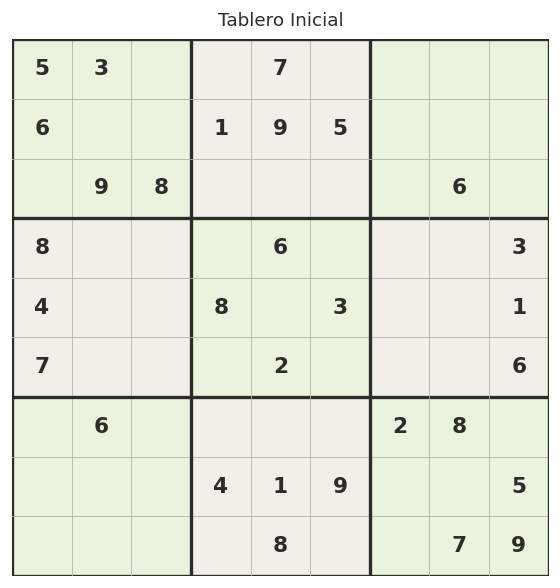

In [2]:
def dibujar_sudoku(tablero, titulo='Sudoku', dado=None, ax=None):
    """
    Dibuja el tablero de Sudoku.
    dado: conjunto de (fila, col) con celdas originales (se pintan diferente).
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))
        standalone = True
    else:
        standalone = False

    ax.set_xlim(0, 9)
    ax.set_ylim(0, 9)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(titulo, fontsize=11, pad=8, color='#2C2C2A')

    # Fondo de subcajas 3×3
    for bi in range(3):
        for bj in range(3):
            color = '#EAF3DE' if (bi + bj) % 2 == 0 else '#F1EFE8'
            rect = patches.Rectangle((bj*3, (2-bi)*3), 3, 3,
                                      facecolor=color, edgecolor='none')
            ax.add_patch(rect)

    # Líneas finas (celdas)
    for i in range(10):
        lw = 2.0 if i % 3 == 0 else 0.5
        color = '#2C2C2A' if i % 3 == 0 else '#B4B2A9'
        ax.axhline(i, 0, 9, color=color, lw=lw)
        ax.axvline(i, 0, 9, color=color, lw=lw)

    # Números
    for i in range(9):
        for j in range(9):
            val = tablero[i][j]
            if val != 0:
                es_dado = dado is None or (i, j) in dado
                color_txt = '#2C2C2A' if es_dado else '#185FA5'
                weight = 'bold' if es_dado else 'normal'
                ax.text(j + 0.5, 8.5 - i, str(val),
                        ha='center', va='center',
                        fontsize=13, color=color_txt,
                        fontweight=weight)

    if standalone:
        plt.tight_layout()
        plt.show()

# Identificar celdas dadas
celdas_dadas = {(i, j) for i in range(9) for j in range(9)
                if tablero_inicial[i][j] != 0}

dibujar_sudoku(tablero_inicial, titulo='Tablero Inicial', dado=celdas_dadas)

## 2. Espacio de Configuraciones y Función de Costo

In [3]:
vacias = sum(tablero_inicial[i][j] == 0
             for i in range(9) for j in range(9))

print('=== Espacio de configuraciones ===')
print(f'Celdas totales:        81')
print(f'Celdas dadas:          {81 - vacias}')
print(f'Celdas vacías:         {vacias}')
print(f'|Ω| sin restricciones: 9^{vacias} ≈ {9**vacias:.3e}')
print()

def contar_conflictos(tablero):
    """Función de costo: número de conflictos (repeticiones)."""
    conflictos = 0
    for i in range(9):
        fila = [tablero[i][j] for j in range(9) if tablero[i][j] != 0]
        conflictos += len(fila) - len(set(fila))
        col = [tablero[j][i] for j in range(9) if tablero[j][i] != 0]
        conflictos += len(col) - len(set(col))
    for bi in range(3):
        for bj in range(3):
            caja = [tablero[bi*3+di][bj*3+dj]
                    for di in range(3) for dj in range(3)
                    if tablero[bi*3+di][bj*3+dj] != 0]
            conflictos += len(caja) - len(set(caja))
    return conflictos

print(f'Conflictos tablero inicial: {contar_conflictos(tablero_inicial)}')
print()
print('Función de costo: f(tablero) = número de conflictos')
print('Objetivo: encontrar tablero con f = 0')

=== Espacio de configuraciones ===
Celdas totales:        81
Celdas dadas:          30
Celdas vacías:         51
|Ω| sin restricciones: 9^51 ≈ 4.638e+48

Conflictos tablero inicial: 0

Función de costo: f(tablero) = número de conflictos
Objetivo: encontrar tablero con f = 0


## 3. Árbol de Búsqueda — Primeros Niveles

Cada nivel asigna un valor a una celda vacía. El **factor de ramificación** varía:
- Sin restricciones: hasta 9 hijos por nodo.
- Con Forward Checking (MRV): se elige primero la celda con menos valores posibles.

In [4]:
def valores_posibles(tablero, fila, col):
    """Devuelve el conjunto de valores válidos para la celda (fila, col)."""
    usados = set()
    usados.update(tablero[fila])                          # fila
    usados.update(tablero[r][col] for r in range(9))      # columna
    bi, bj = (fila // 3) * 3, (col // 3) * 3
    usados.update(tablero[bi+di][bj+dj]                   # caja 3×3
                  for di in range(3) for dj in range(3))
    return set(range(1, 10)) - usados

def mrv(tablero):
    """Minimum Remaining Values: celda vacía con menos opciones."""
    mejor, min_ops = None, 10
    for i in range(9):
        for j in range(9):
            if tablero[i][j] == 0:
                ops = len(valores_posibles(tablero, i, j))
                if ops < min_ops:
                    mejor, min_ops = (i, j), ops
    return mejor

# Mostrar los primeros 3 niveles del árbol
print('Árbol de búsqueda — primeros 3 niveles (con MRV)\n')
print('Nivel 0 (Raíz): tablero inicial')

c0 = mrv(tablero_inicial)
ops0 = sorted(valores_posibles(tablero_inicial, *c0))
print(f'\nNivel 1 → celda MRV: {c0}, valores posibles: {ops0}')

for v0 in ops0[:3]:   # sólo los 3 primeros hijos para no saturar la salida
    t1 = deepcopy(tablero_inicial)
    t1[c0[0]][c0[1]] = v0
    c1 = mrv(t1)
    if c1:
        ops1 = sorted(valores_posibles(t1, *c1))
        print(f'  ├─ celda {c0}={v0}  →  Nivel 2: celda MRV {c1}, opciones {ops1}')
        for v1 in ops1[:2]:
            t2 = deepcopy(t1)
            t2[c1[0]][c1[1]] = v1
            c2 = mrv(t2)
            if c2:
                ops2 = sorted(valores_posibles(t2, *c2))
                print(f'  │   ├─ celda {c1}={v1}  →  Nivel 3: celda MRV {c2}, opciones {ops2}')

print('\n  (ramas podadas cuando valores_posibles = ∅ → backtrack)')

Árbol de búsqueda — primeros 3 niveles (con MRV)

Nivel 0 (Raíz): tablero inicial

Nivel 1 → celda MRV: (4, 4), valores posibles: [5]
  ├─ celda (4, 4)=5  →  Nivel 2: celda MRV (4, 1), opciones [2]
  │   ├─ celda (4, 1)=2  →  Nivel 3: celda MRV (4, 7), opciones [9]

  (ramas podadas cuando valores_posibles = ∅ → backtrack)


## 4. Visualización del árbol (grafo primeros 2 niveles)

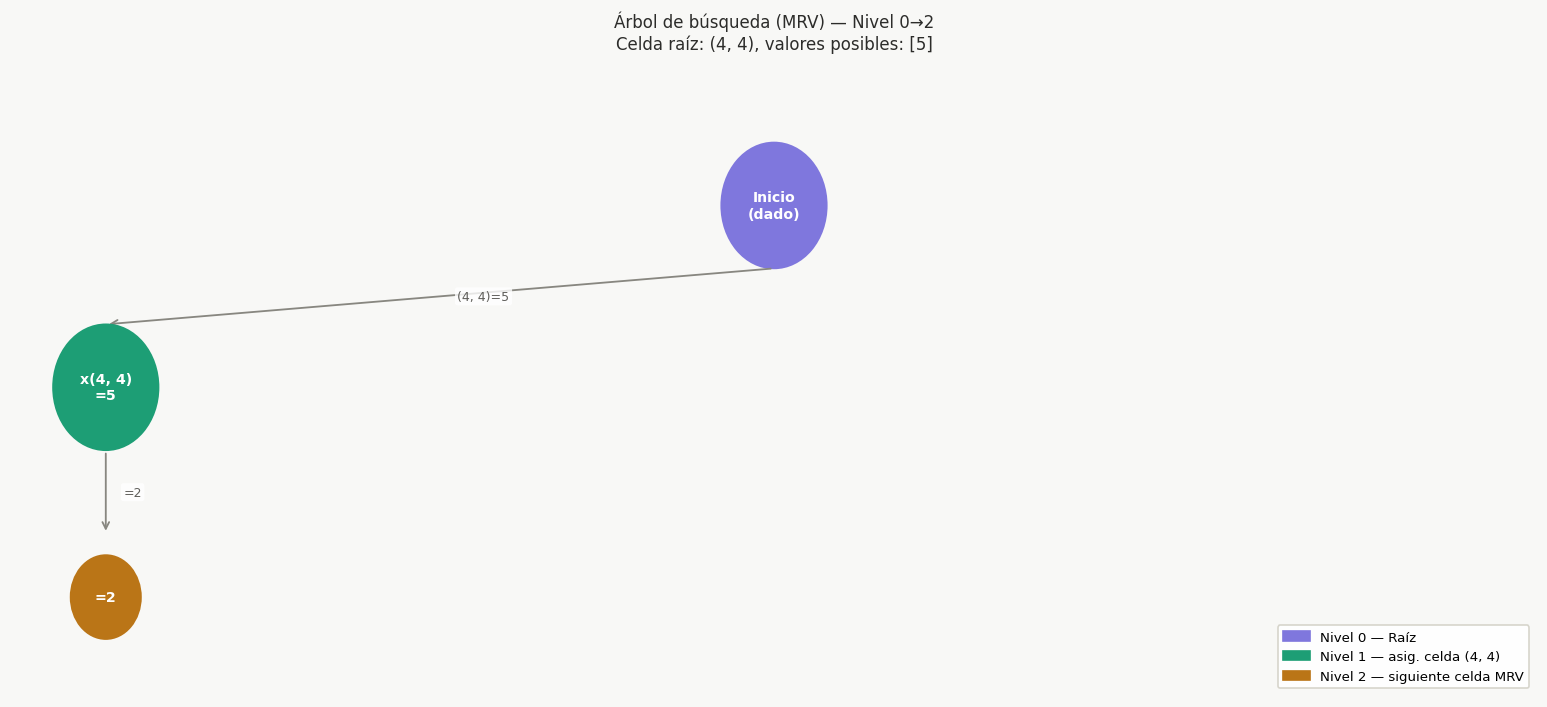

In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(13, 6))
ax.set_facecolor('#F8F8F6')
fig.patch.set_facecolor('#F8F8F6')
ax.axis('off')
ax.set_xlim(0, 13)
ax.set_ylim(-3.5, 1)

PALETA = {
    0: ('#7F77DD', 'white'),   # raíz — púrpura
    1: ('#1D9E75', 'white'),   # nivel 1 — teal
    2: ('#BA7517', 'white'),   # nivel 2 — ámbar
}

def dibujar_nodo(ax, cx, cy, texto, nivel, radio=0.45):
    color, tcolor = PALETA[nivel]
    circ = plt.Circle((cx, cy), radio, color=color, zorder=3)
    ax.add_patch(circ)
    ax.text(cx, cy, texto, ha='center', va='center',
            fontsize=8.5, color=tcolor, fontweight='bold', zorder=4)

def dibujar_arista(ax, x1, y1, x2, y2, etiqueta=''):
    ax.annotate('', xy=(x2, y2+0.45), xytext=(x1, y1-0.45),
                arrowprops=dict(arrowstyle='->', color='#888780', lw=1.1))
    mx, my = (x1+x2)/2, (y1+y2)/2
    if etiqueta:
        ax.text(mx+0.15, my, etiqueta, ha='left', va='center',
                fontsize=7.5, color='#5F5E5A',
                bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.8))

# Raíz
dibujar_nodo(ax, 6.5, 0, 'Inicio\n(dado)', 0)

# Nivel 1
c0 = mrv(tablero_inicial)
ops0 = sorted(valores_posibles(tablero_inicial, *c0))
n1 = len(ops0)
xs1 = np.linspace(0.8, 12.2, n1)

for idx, v0 in enumerate(ops0):
    x1 = xs1[idx]
    dibujar_arista(ax, 6.5, 0, x1, -1.3, f'{c0}={v0}')
    t1 = deepcopy(tablero_inicial)
    t1[c0[0]][c0[1]] = v0
    c1 = mrv(t1)
    ops1 = sorted(valores_posibles(t1, *c1)) if c1 else []
    n2 = len(ops1)
    label_n1 = f'x{c0}\n={v0}'
    dibujar_nodo(ax, x1, -1.3, label_n1, 1)

    # Nivel 2 (solo primeros 2 hijos por nodo nivel-1)
    if ops1 and idx < 5:   # limitar para no saturar
        sub = ops1[:2]
        spread = 0.55
        xs2 = [x1 + (i - (len(sub)-1)/2) * spread for i in range(len(sub))]
        for jdx, v1 in enumerate(sub):
            x2 = xs2[jdx]
            dibujar_arista(ax, x1, -1.3, x2, -2.8, f'={v1}')
            dibujar_nodo(ax, x2, -2.8, f'={v1}', 2, radio=0.3)
        if len(ops1) > 2:
            ax.text(x1 + 0.35, -2.8, f'+{len(ops1)-2}…',
                    va='center', fontsize=7, color='#888780')

# Leyenda
legend_items = [
    mpatches.Patch(color='#7F77DD', label='Nivel 0 — Raíz'),
    mpatches.Patch(color='#1D9E75', label=f'Nivel 1 — asig. celda {c0}'),
    mpatches.Patch(color='#BA7517', label='Nivel 2 — siguiente celda MRV'),
]
ax.legend(handles=legend_items, loc='lower right', fontsize=8,
          framealpha=0.9, edgecolor='#D3D1C7')

ax.set_title(f'Árbol de búsqueda (MRV) — Nivel 0→2\n'
             f'Celda raíz: {c0}, valores posibles: {ops0}',
             fontsize=10, pad=10, color='#2C2C2A')

plt.tight_layout()
plt.savefig('arbol_sudoku.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Solucionador — Backtracking + MRV

In [6]:
stats = {'nodos': 0, 'podas': 0}

def resolver(tablero):
    """
    Backtracking con MRV (Minimum Remaining Values).
    Retorna True si encontró solución, modificando tablero in-place.
    """
    celda = mrv(tablero)
    if celda is None:
        return True   # todas las celdas asignadas → solución

    fila, col = celda
    for val in sorted(valores_posibles(tablero, fila, col)):
        stats['nodos'] += 1
        tablero[fila][col] = val
        if resolver(tablero):
            return True
        tablero[fila][col] = 0   # backtrack
        stats['podas'] += 1

    return False

solucion = deepcopy(tablero_inicial)
exito = resolver(solucion)

print(f'Solución encontrada: {exito}')
print(f'Nodos explorados:    {stats["nodos"]}')
print(f'Backtracks:          {stats["podas"]}')
print(f'Conflictos finales:  {contar_conflictos(solucion)}')

Solución encontrada: True
Nodos explorados:    51
Backtracks:          0
Conflictos finales:  0


## 6. Visualización de la solución

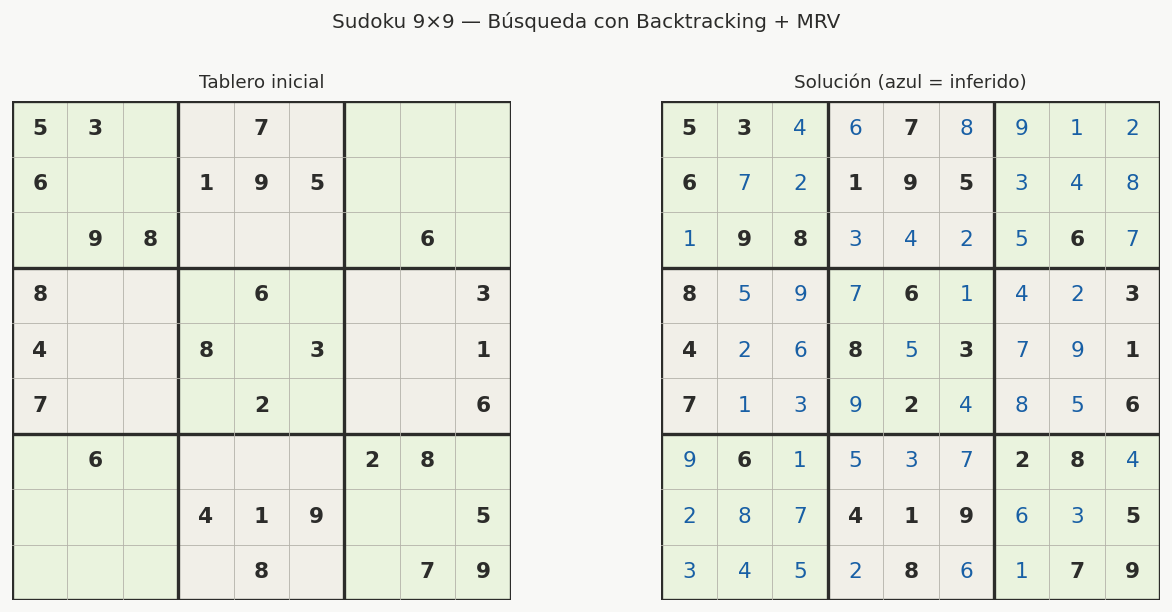


Solución completa:
[5, 3, 4, 6, 7, 8, 9, 1, 2]
[6, 7, 2, 1, 9, 5, 3, 4, 8]
[1, 9, 8, 3, 4, 2, 5, 6, 7]
[8, 5, 9, 7, 6, 1, 4, 2, 3]
[4, 2, 6, 8, 5, 3, 7, 9, 1]
[7, 1, 3, 9, 2, 4, 8, 5, 6]
[9, 6, 1, 5, 3, 7, 2, 8, 4]
[2, 8, 7, 4, 1, 9, 6, 3, 5]
[3, 4, 5, 2, 8, 6, 1, 7, 9]


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
fig.patch.set_facecolor('#F8F8F6')

dibujar_sudoku(tablero_inicial, titulo='Tablero inicial',
               dado=celdas_dadas, ax=axes[0])
dibujar_sudoku(solucion, titulo='Solución (azul = inferido)',
               dado=celdas_dadas, ax=axes[1])

plt.suptitle('Sudoku 9×9 — Búsqueda con Backtracking + MRV',
             fontsize=12, y=1.01, color='#2C2C2A')
plt.tight_layout()
plt.savefig('sudoku_solucion.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nSolución completa:')
for fila in solucion:
    print(fila)